**Visualization and numerical investigation of the equations for heliospheric current sheet drift in the `helmod2012` and `helmod2018` models.**

In [1]:
import numpy as np
import sympy as sp

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 30.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.titlesize'] = 'small'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xaxis.labellocation'] = 'right'
plt.rcParams['yaxis.labellocation'] = 'top'
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['figure.figsize'] = (18, 10)

In [3]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'

In [4]:
theta, ah, ch = sp.symbols('vartheta a_h c_h', positive=True)

In [5]:
f1 = 1/ah*sp.atan((1-(2*theta/sp.pi))*sp.tan(ah))

atan((-2*vartheta/pi + 1)*tan(a_h))/a_h

In [6]:
f = sp.Piecewise((f1, ch < sp.pi/2), (1-2*sp.Heaviside(theta-sp.pi/2), sp.Eq(ch, sp.pi/2)), (0, True))

Piecewise((atan((-2*vartheta/pi + 1)*tan(a_h))/a_h, c_h < pi/2), (1 - 2*Heaviside(vartheta - pi/2), Eq(c_h, pi/2)), (0, True))

In [7]:
f2 = f.subs(ah, sp.acos(sp.pi/(2*ch)-1))

Piecewise((atan(sqrt(1 - (-1 + pi/(2*c_h))**2)*(-2*vartheta/pi + 1)/(-1 + pi/(2*c_h)))/acos(-1 + pi/(2*c_h)), c_h < pi/2), (1 - 2*Heaviside(vartheta - pi/2), Eq(c_h, pi/2)), (0, True))

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


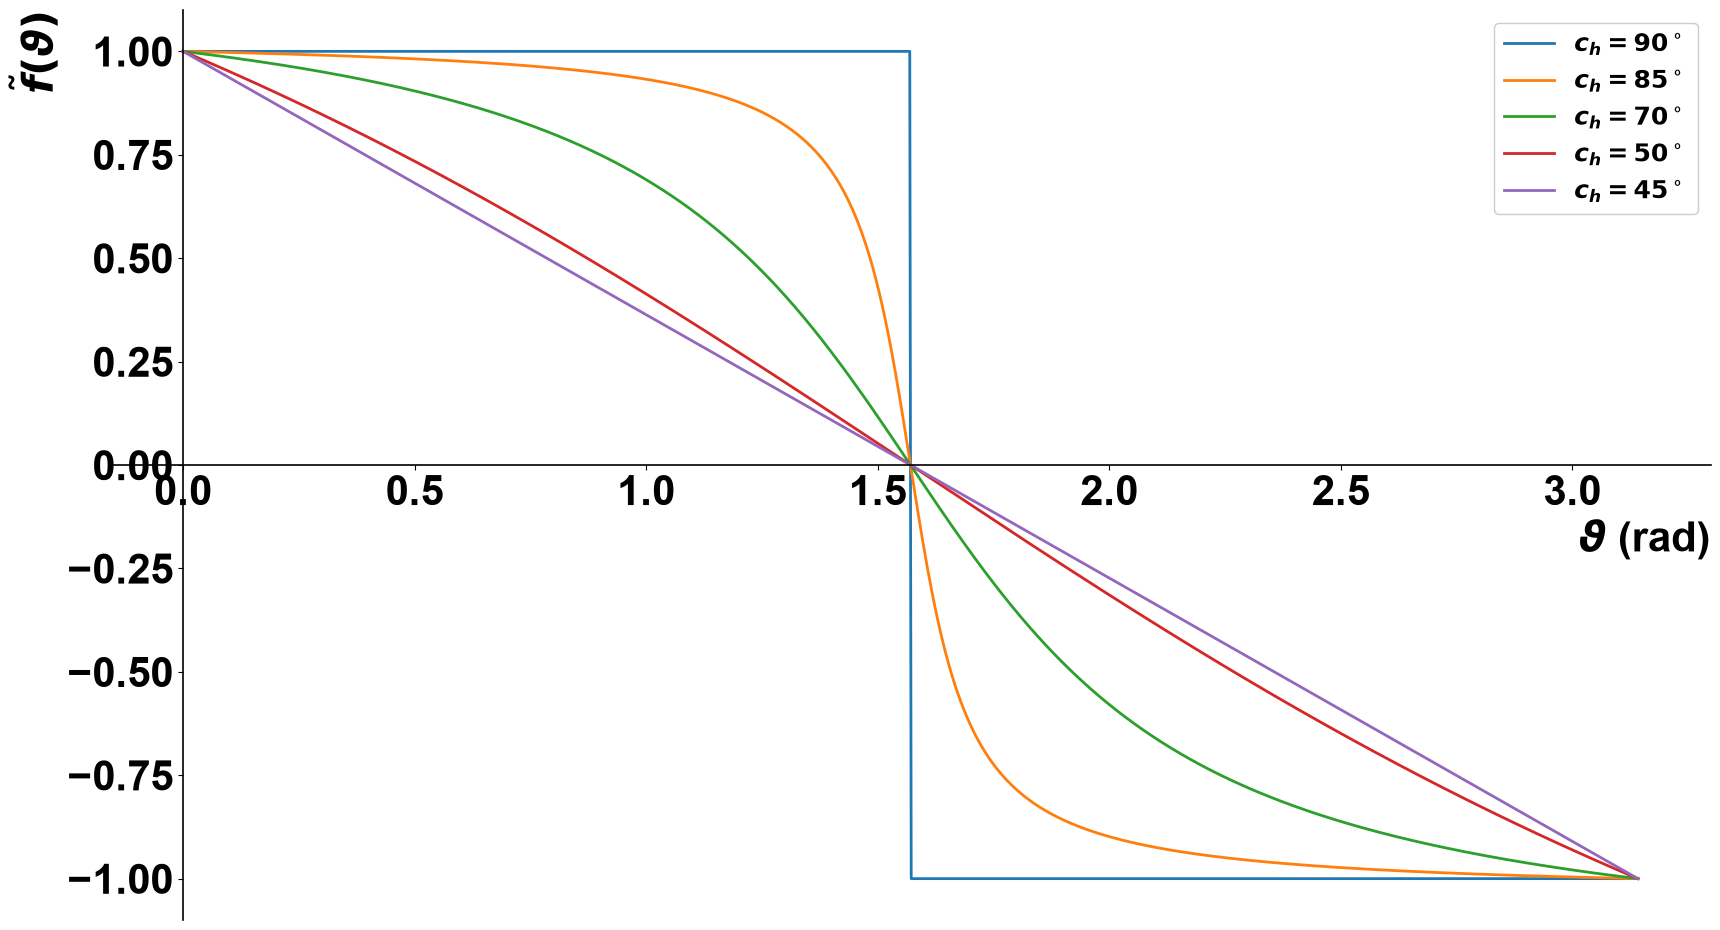

In [8]:
p90 = sp.plot(f2.subs(ch, np.deg2rad(90.)), (theta, 0, sp.pi), show=False, label=r'$c_h=90^\circ$', legend=True, ylabel=r'$\tilde{f}(\vartheta)$', xlabel=r'$\vartheta$ (rad)')
p85 = sp.plot(f2.subs(ch, np.deg2rad(85.)), (theta, 0, sp.pi), show=False, label=r'$c_h=85^\circ$')
p70 = sp.plot(f2.subs(ch, np.deg2rad(70.)), (theta, 0, sp.pi), show=False, label=r'$c_h=70^\circ$')
p50 = sp.plot(f2.subs(ch, np.deg2rad(50.)), (theta, 0, sp.pi), show=False, label=r'$c_h=50^\circ$')
p45 = sp.plot(f2.subs(ch, np.deg2rad(45.)), (theta, 0, sp.pi), show=False, label=r'$c_h=45^\circ$')
p90.extend(p85)
p90.extend(p70)
p90.extend(p50)
p90.extend(p45)
p90.show()

In [9]:
sp.simplify(f2.subs(theta, ch))

Piecewise((atan(sqrt(4*c_h - pi)/sqrt(pi))/acos(-1 + pi/(2*c_h)), c_h < pi/2), (1 - 2*Heaviside(c_h - pi/2), Eq(c_h, pi/2)), (0, True))

In [10]:
f1p = sp.diff(f1, theta)

-2*tan(a_h)/(pi*a_h*((-2*vartheta/pi + 1)**2*tan(a_h)**2 + 1))

In [11]:
fprime = sp.Piecewise((f1p, ch < sp.pi/2), (0, True))

Piecewise((-2*tan(a_h)/(pi*a_h*((-2*vartheta/pi + 1)**2*tan(a_h)**2 + 1)), c_h < pi/2), (0, True))

In [12]:
fp2 = sp.simplify(fprime.subs(ah, sp.acos(sp.pi/(2*ch)-1)))

Piecewise((sqrt(pi)*(c_h - pi/2)*sqrt(4*c_h - pi)/((pi*c_h**2 + 4*c_h*vartheta**2 - 4*pi*c_h*vartheta - pi*vartheta**2 + pi**2*vartheta)*acos((pi - 2*c_h)/(2*c_h))), c_h < pi/2), (0, True))

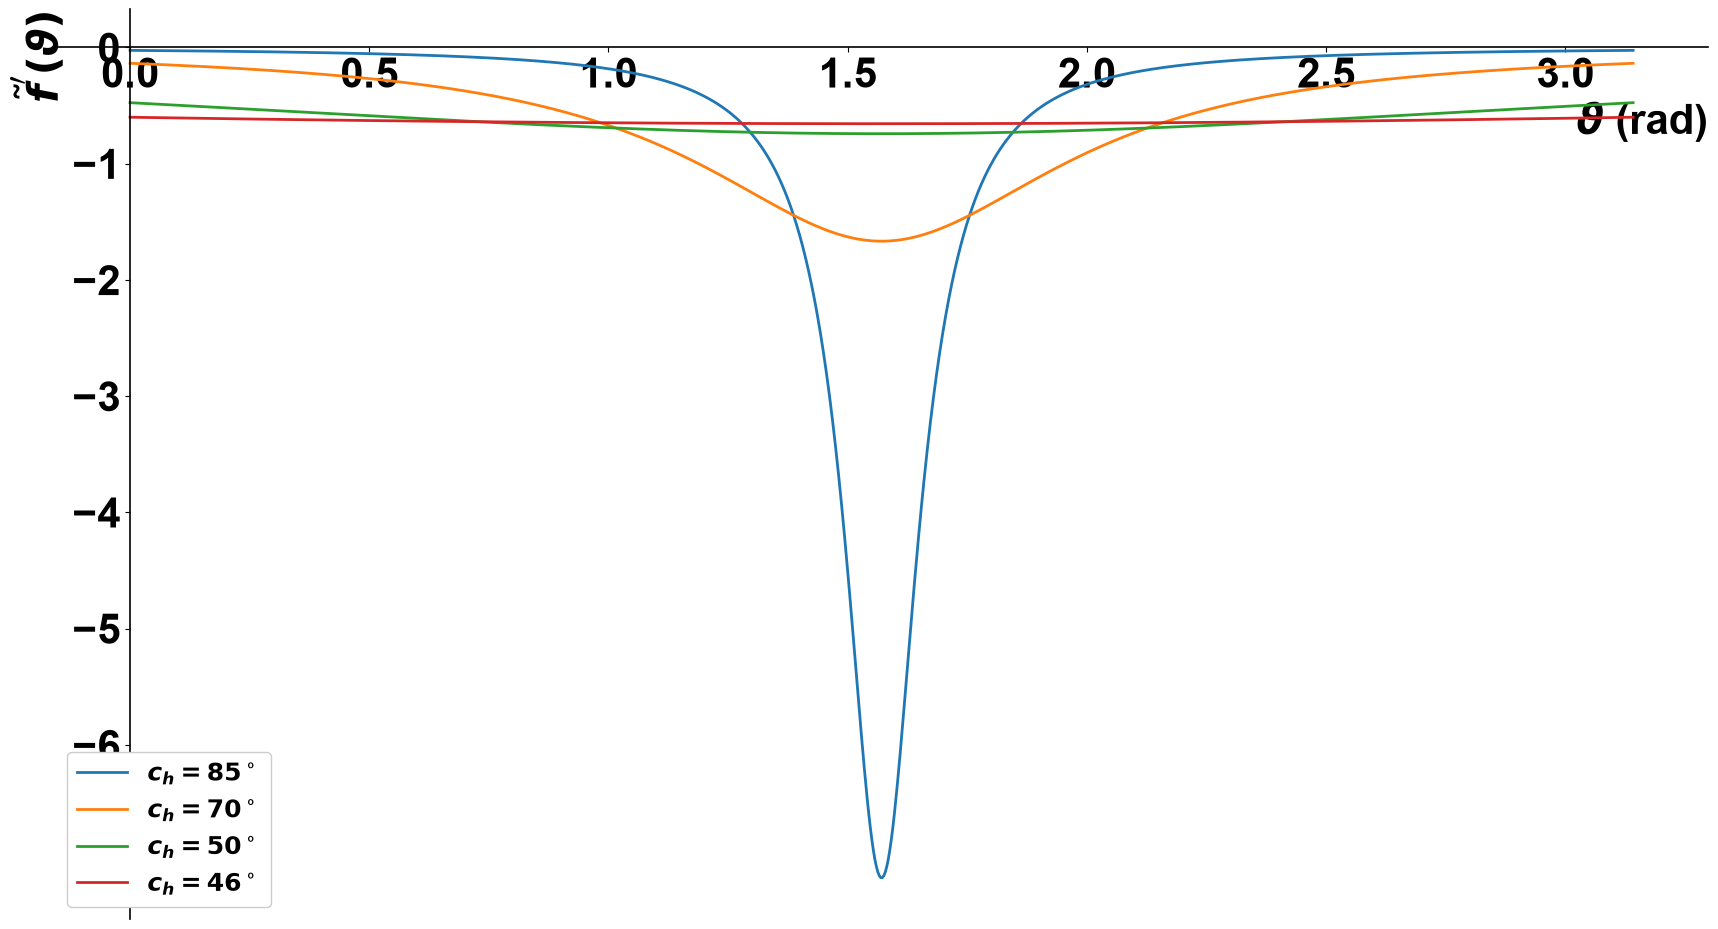

In [13]:
pp85 = sp.plot(fp2.subs(ch, np.deg2rad(85.)), (theta, 0, sp.pi), show=False, label=r'$c_h=85^\circ$', legend=True, ylabel=r'$\tilde{f}^\prime(\vartheta)$', xlabel=r'$\vartheta$ (rad)')
pp70 = sp.plot(fp2.subs(ch, np.deg2rad(70.)), (theta, 0, sp.pi), show=False, label=r'$c_h=70^\circ$')
pp50 = sp.plot(fp2.subs(ch, np.deg2rad(50.)), (theta, 0, sp.pi), show=False, label=r'$c_h=50^\circ$')
pp46 = sp.plot(fp2.subs(ch, np.deg2rad(46.)), (theta, 0, sp.pi), show=False, label=r'$c_h=46^\circ$')
pp85.extend(pp70)
pp85.extend(pp50)
pp85.extend(pp46)
pp85.show()

In [14]:
fp2.subs(ch, sp.pi/2).subs(theta, sp.pi/2)

0

In [15]:
(-1/(sp.pi/2)).evalf()

-0.636619772367581

In [16]:
x, xi = sp.symbols('x xi', real=True)

In [17]:
xi_expr = (1-(2*theta/sp.pi))*sp.tan(ah)

(-2*vartheta/pi + 1)*tan(a_h)

In [18]:
f1.subs(xi_expr, xi)

atan(xi)/a_h

In [19]:
f1p_xi = f1p.subs(xi_expr, xi)

-2*tan(a_h)/(pi*a_h*(xi**2 + 1))

In [20]:
print(sp.ccode(f1p_xi))

-2*tan(a_h)/(M_PI*a_h*(pow(xi, 2) + 1))


In [21]:
atilt, deltatheta = sp.symbols('alpha_tilt Delta_HCS')

In [22]:
chf = sp.pi/2-sp.sin(atilt+deltatheta)/2

-sin(Delta_HCS + alpha_tilt)/2 + pi/2

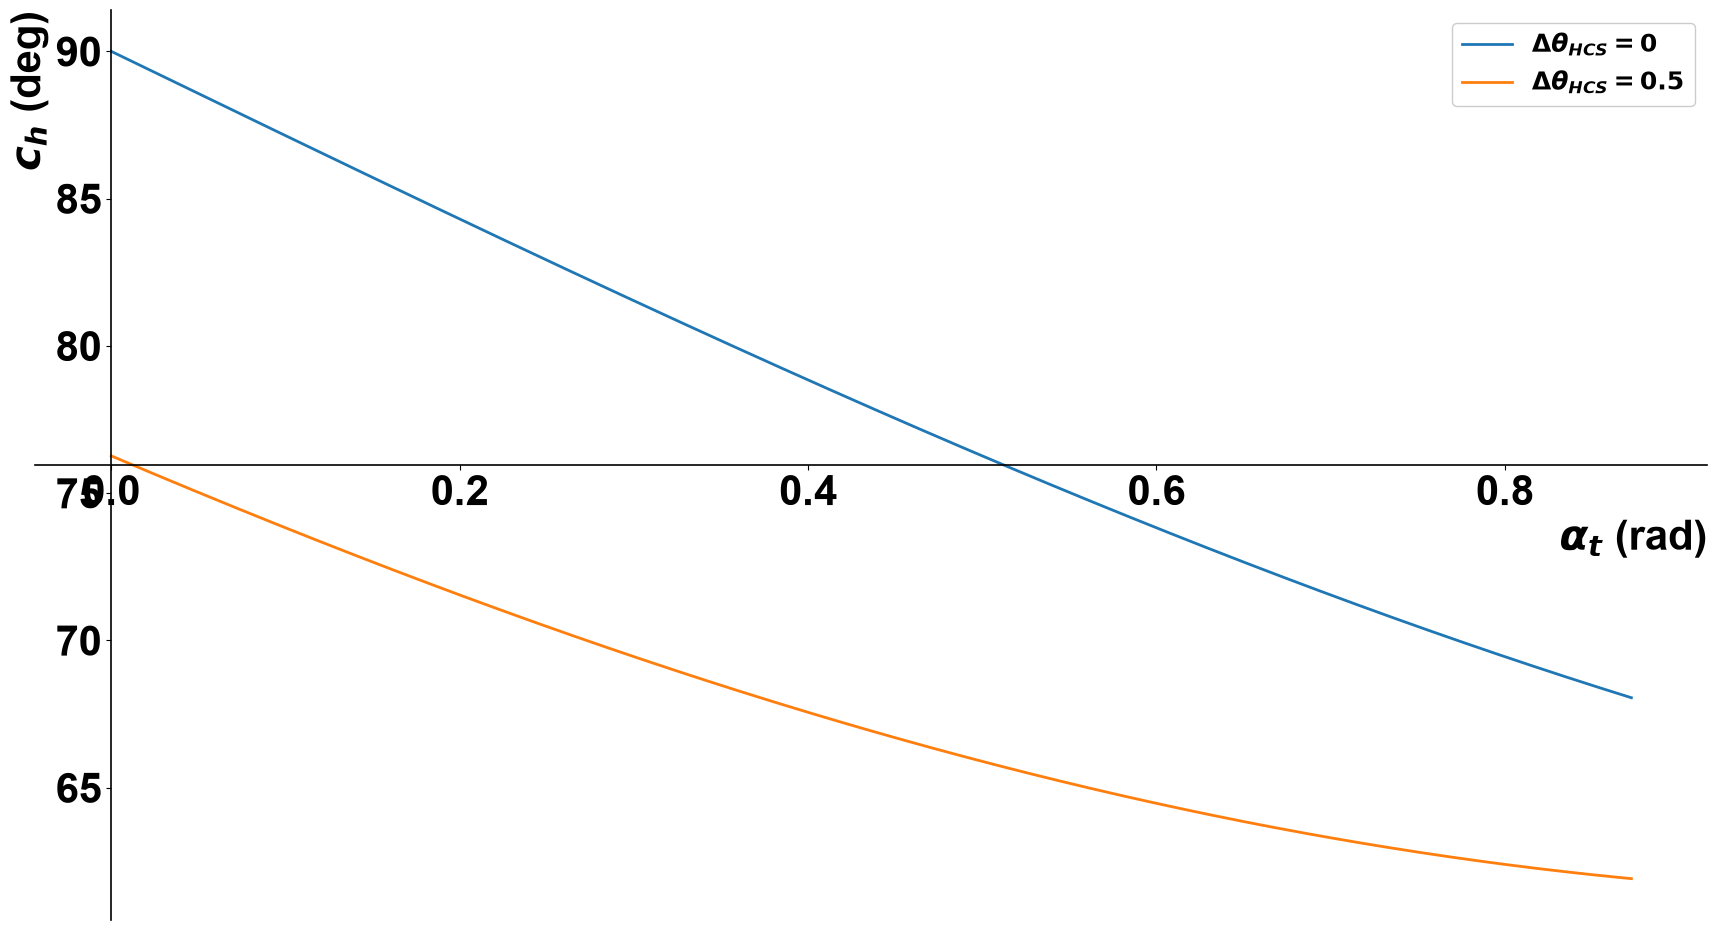

In [23]:
pc0 = sp.plot(chf.subs(deltatheta, 0)/sp.pi*180, (atilt, 0, np.deg2rad(50.)), ylabel='$c_h$ (deg)', xlabel=r'$\alpha_{t}$ (rad)', label=r'$\Delta\theta_{HCS}=0$',legend=True, show=False)
pc1 = sp.plot(chf.subs(deltatheta, 0.5)/sp.pi*180, (atilt, 0, np.deg2rad(50.)), label=r'$\Delta\theta_{HCS}=0.5$', show=False)
pc0.extend(pc1)
pc0.show()

In [24]:
np.rad2deg(1.0).round(2)

np.float64(57.3)

In [25]:
from sympy.vector import CoordSys3D
#P = CoordSys3D('P', transformation='spherical', vector_names=list('rtp'), variable_names=list('RTP'))
P = CoordSys3D('P', transformation='spherical', vector_names=['e_r', 'e_{theta}', 'e_{phi}'], variable_names=list('RTP'))

P

In [26]:
er = P.base_vectors()[0]
et = P.base_vectors()[1]
ep = P.base_vectors()[2]

P.e_{phi}

In [27]:
er.cross(et)

P.e_{phi}

In [28]:
Br, Bt, Bp = sp.symbols('B_r B_theta B_phi', real=True)

In [29]:
B = Br*er + Bt*et + Bp*ep

B_r*P.e_r + B_theta*P.e_{theta} + B_phi*P.e_{phi}

In [30]:
et.cross(B)

B_phi*P.e_r + (-B_r)*P.e_{phi}

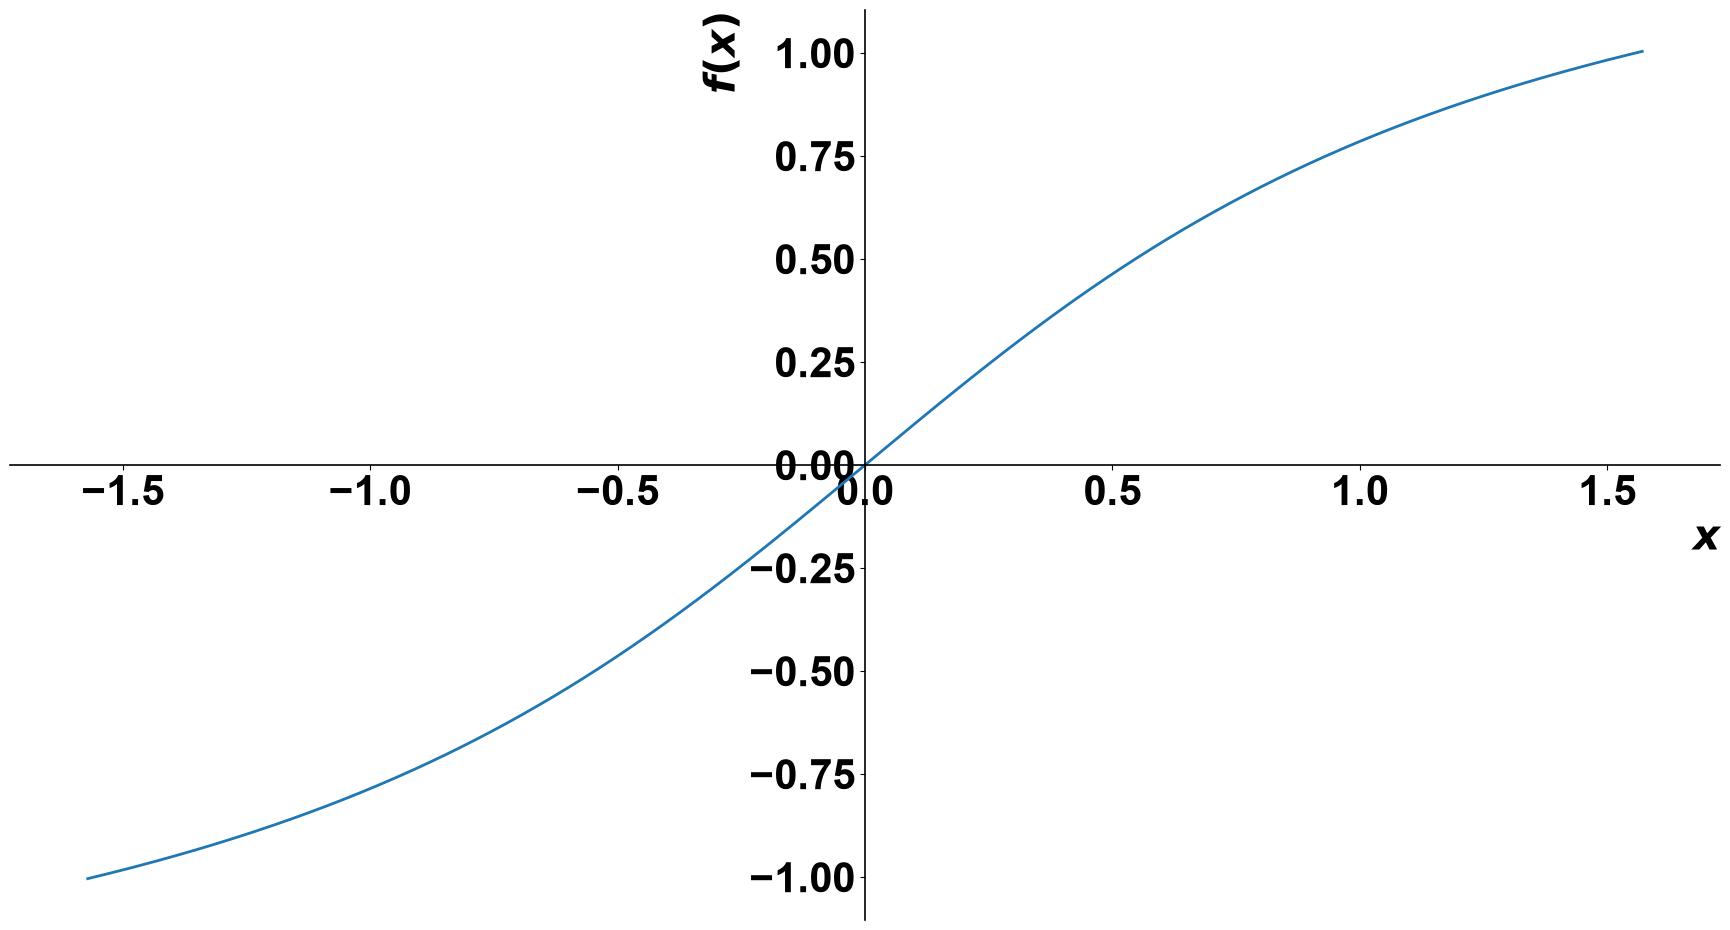

In [31]:
sp.plot(sp.atan(x), (x, -sp.pi/2, sp.pi/2))

Approximation for $\Delta\theta_\mathrm{HCS}$

In [32]:
A, B0, r0, r, Gamma, R = sp.symbols('A B_0 r_0 r Gamma R', positive=True)

In [33]:
Omega, vsw = sp.symbols('Omega v_sw', positive=True)

In [34]:
Bphi = A*B0*r0**2/r**2*(-Gamma)

-A*B_0*Gamma*r_0**2/r**2

In [35]:
deltatheta = 2*R/Bphi/r

-2*R*r/(A*B_0*Gamma*r_0**2)

In [36]:
-deltatheta.subs(Gamma, Omega*r*sp.sin(theta)/vsw).subs(theta, sp.pi/2-atilt)

2*R*v_sw/(A*B_0*Omega*r_0**2*cos(alpha_tilt))

In [37]:
rigidity_scale = 1/(2*vsw/Omega/B0/r0**2)

B_0*Omega*r_0**2/(2*v_sw)

In [38]:
from astropy import units as u
from astropy import constants as const

In [39]:
vOmega = 2.*np.pi/(25.4*u.day)

<Quantity 0.2473695 1 / d>

In [40]:
vr0 = 1.*u.AU

<Quantity 1. AU>

In [41]:
vB0 = 3.4*u.nanotesla

<Quantity 3.4 nT>

In [42]:
vvsw = 400.*u.km/u.s

<Quantity 400. km / s>

In [43]:
rigidity_scale_func = sp.lambdify([Omega, r0, B0, vsw], rigidity_scale)

<function _lambdifygenerated(Omega, r_0, B_0, v_sw)>

In [44]:
Rscale = rigidity_scale_func(Omega=vOmega, r_0=vr0, B_0=vB0, v_sw=vvsw)

<Quantity 0.00105132 AU2 nT s / (d km)>

In [45]:
const.c

<<class 'astropy.constants.codata2018.CODATA2018'> name='Speed of light in vacuum' value=299792458.0 uncertainty=0.0 unit='m / s' reference='CODATA 2018'>

In [46]:
(Rscale / (u.gigavolt/const.c)).decompose()

<Quantity 81.63809581>

In [47]:
(u.gigavolt/const.c*const.c/3/u.AU/vB0).decompose()

<Quantity 655351.67865377 m / s>